# Performance Analysis - Study 2a

## Loading the libraries

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader.data as web
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import itertools
from scipy import stats
import seaborn as sns
import matplotlib as mpl

## Loading the data

In [2]:
df = pd.read_csv('./data/ageRisk_long.csv', index_col=0)

## Fetching performance data & calculating performance measures

In [3]:
benchmark_ticker = 'VT'
start_date = '2023-07-01'
end_date = '2025-01-01' # we calculate the performance over the 6 month following the financial advice data collection
market_data = {}

# Fetches the annualized risk free rate from FRED 
def fetch_risk_free_rate():
    risk_free_data = web.DataReader("DGS10", "fred").loc[start_date:end_date]
    risk_free_rate = risk_free_data.mean() / 100
    risk_free_rate = risk_free_rate['DGS10']
    return risk_free_rate
    
risk_free_rate = fetch_risk_free_rate()

In [29]:
# Fetches pricing data for assets from Yahoo Finance
def get_market_data(tickers):
    for ticker in tickers:
        if ticker in market_data:
            return
        else:
            try:
                prices = yf.download(ticker, start=start_date, end=end_date)['Close']
                market_data[ticker] = prices
            except:
                market_data[ticker] = pd.Series([1 for _ in range(len(market_data[next(iter(market_data))]))], 
                                               index=market_data[next(iter(market_data))].index)

def calc_performance_metrics(portfolio_returns):
    endpoints = portfolio_returns.resample('M').last().index
    expanding_returns = []
    expanding_volatility = []
    expanding_sharpe_ratios = []
    
    for date in endpoints:
        period_returns = portfolio_returns.loc[:date]
        n_weeks= len(pd.date_range(start=start_date, end=date, freq='W'))

        # Calculate cumulative returns
        cumulative_return = (1 + period_returns).prod() - 1
        
        # Calculate annualized and annualized excess return for Sharpe ratio
        annualized_return = (1 + cumulative_return) ** (52 / n_weeks) - 1
        excess_return = annualized_return - risk_free_rate
        
        # Calculate annualized volatility 
        weekly_returns = (1 + period_returns).resample('W').prod() - 1
        weekly_volatility = weekly_returns.std()
        annualized_volatility = weekly_volatility * np.sqrt(52)

        # Calculate Sharpe ratio
        sharpe_ratio = excess_return / annualized_volatility if annualized_volatility > 0 else np.nan
        
        expanding_returns.append(cumulative_return)
        expanding_volatility.append(annualized_volatility)
        expanding_sharpe_ratios.append(sharpe_ratio)

    return expanding_returns, expanding_volatility, expanding_sharpe_ratios, endpoints

    

def get_portfolio_data(df, group_cols):
    get_market_data(df['ticker_symbol'].dropna().unique())

    portfolio_df = []  # For time-series data
    grouped = df.groupby(group_cols)

    for name, group in grouped:
        total_investment = group['amount_to_invest'].sum()
        weights = group['amount_to_invest'] / total_investment
        prices_df = pd.DataFrame()
        
        for i, ticker in enumerate(group['ticker_symbol']):
            if ticker in market_data:
                prices_df[ticker] = market_data[ticker]
            else:
                # Assume no return and no standard deviation for invalid/ Nan tickers
                prices_df[f'{ticker}_{i}'] = pd.Series([1 for _ in range(len(market_data[next(iter(market_data))]))], 
                                              index=market_data[next(iter(market_data))].index)
        
        prices_df = prices_df.ffill().bfill().fillna(1) # fill the price value for equities on the weekend with the last price for portfolios with cryptos 

        # Calculate daily portfolio returns
        daily_returns = prices_df.pct_change().fillna(0)
        portfolio_returns = (daily_returns * weights.values).sum(axis=1)

        expanding_returns, expanding_volatility, expanding_sharpe_ratios, endpoints = calc_performance_metrics(portfolio_returns)
          
        df_temp = pd.DataFrame({
            'cond': name[0],
            'age': name[1],
            'risk-taking': name[2],
            'iteration': name[3],
            'date': endpoints,
            'portfolio_cumulative_return': expanding_returns,
            'portfolio_std_dev': expanding_volatility,
            'sharpe_ratio': expanding_sharpe_ratios,
        })
        portfolio_df.append(df_temp)

    return pd.concat(portfolio_df, ignore_index=True)


# Get time-series data and final summary values
group_cols = ['cond', 'age', 'risk-taking', 'iteration']    
portfolio_time_series_df = get_portfolio_data(df, group_cols)

# Save performance data
portfolio_time_series_df.to_csv('./data/performance_weekly.csv')


In [30]:
def get_benchmark_performance(ticker):
    get_market_data([ticker])
    prices_df = pd.DataFrame()
    prices_df[ticker]  = market_data[ticker]
    prices_df = prices_df.ffill().bfill().fillna(1)
    
    daily_returns = prices_df.pct_change().fillna(0)
    benchmark_returns = daily_returns.sum(axis=1)

    expanding_returns, expanding_volatility, expanding_sharpe_ratios, endpoints = calc_performance_metrics(benchmark_returns)

    df_tmp = pd.DataFrame({
            'cond': 'Benchmark (VT)',
            'date': endpoints,
            'portfolio_cumulative_return': expanding_returns,
            'portfolio_std_dev': expanding_volatility,
            'sharpe_ratio': expanding_sharpe_ratios,
        })

    return df_tmp

benchmark_timeseries = get_benchmark_performance(benchmark_ticker)
benchmark_timeseries.to_csv('./data/performance_benchmark_weekly.csv')

## Analysis

In [31]:
mpl.rcParams['font.size'] = 14
mpl.rcParams['font.sans-serif'] = 'Arial'

In [32]:
portfolios_timeseries = pd.read_csv('./data/performance_weekly.csv', index_col=0)
benchmark_timeseries = pd.read_csv('./data/performance_benchmark_weekly.csv', index_col=0)

portfolios_timeseries['date'] = pd.to_datetime(portfolios_timeseries['date'])
benchmark_timeseries['date'] = pd.to_datetime(benchmark_timeseries['date'])

portfolios_timeseries['portfolio_cumulative_return'] = portfolios_timeseries['portfolio_cumulative_return'] * 100
benchmark_timeseries['portfolio_cumulative_return'] = benchmark_timeseries['portfolio_cumulative_return'] * 100

portfolios_timeseries['risk-taking'] = portfolios_timeseries['risk-taking'].replace({'averse':'low', 'neutral':'medium', 'seeking':'high'})
portfolios_timeseries['risk-taking'] = pd.Categorical(portfolios_timeseries['risk-taking'], categories=['low', 'medium', 'high'], ordered=True)
portfolios_timeseries.sort_values(by='risk-taking', inplace=True)


In [40]:
def plot_timeline(raw, raw_benchmark, column, ylab, groups, filename):
    grouped = raw.groupby(groups, observed=False)[column].mean().reset_index()
    grouped = grouped.sort_values(by='date')
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=grouped, x='date', y=column, hue='cond', marker='o', linewidth=2.5)

    plt.plot(raw_benchmark['date'], 
             raw_benchmark[column], 
             label='Benchmark (VT)', 
             color='black', 
             linestyle='--', 
             linewidth=2.5, 
             marker='o',
             alpha=.75
            )
    
    plt.xlabel('Date')
    plt.ylabel(ylab)
    plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
    plt.legend(title='')
    plt.grid(True, alpha=.3)
    plt.tight_layout()

    plt.savefig(f'./figures/{filename}.png')
    plt.show()

def plot_timeline_detailed(raw, raw_benchmark, column, ylab, group, group_lab, filename):
    groups = ['date', 'cond', group]
    grouped = raw.groupby(groups, observed=False)[column].mean().reset_index()
    grouped = grouped.sort_values(by=groups)
    
    unique_conds = grouped['cond'].unique()
    base_colors = sns.color_palette("deep", n_colors=len(unique_conds))
    
    color_dict = {}
    for i, cond in enumerate(unique_conds):
        cond_data = grouped[grouped['cond'] == cond]
        group_groups = cond_data[group].unique()
        base_color = base_colors[i]
        
        for j, elem in enumerate(group_groups):
            color_dict[f"{cond}_{elem}"] = sns.set_hls_values(
                base_color, 
                l=max(0.3, 0.65 - j * 0.15)  # Adjust lightness
            )
    
    plt.figure(figsize=(12, 6))
    
    # Plot lines for each Cond-group combination
    for cond in unique_conds:
        cond_data = grouped[grouped['cond'] == cond]
        for elem in cond_data[group].unique():
            data = cond_data[cond_data[group] == elem]
            plt.plot(data['date'], 
                    data[column],
                    label=f"{cond} / {elem}",
                    color=color_dict[f"{cond}_{elem}"],
                    marker="o",
                    linewidth=2.5)
    
    # Add benchmark
    plt.plot(raw_benchmark['date'], 
             raw_benchmark[column], 
             label='Benchmark (VT)', 
             color='black', 
             linestyle='--', 
             linewidth=2.5, 
             marker='o',
             alpha=.6)
    
    plt.xlabel('Date')
    plt.ylabel(ylab)
    plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
    plt.legend(title=f'Condition / {group_lab}', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(f'./figures/{filename}.png')
    plt.show()

### Returns

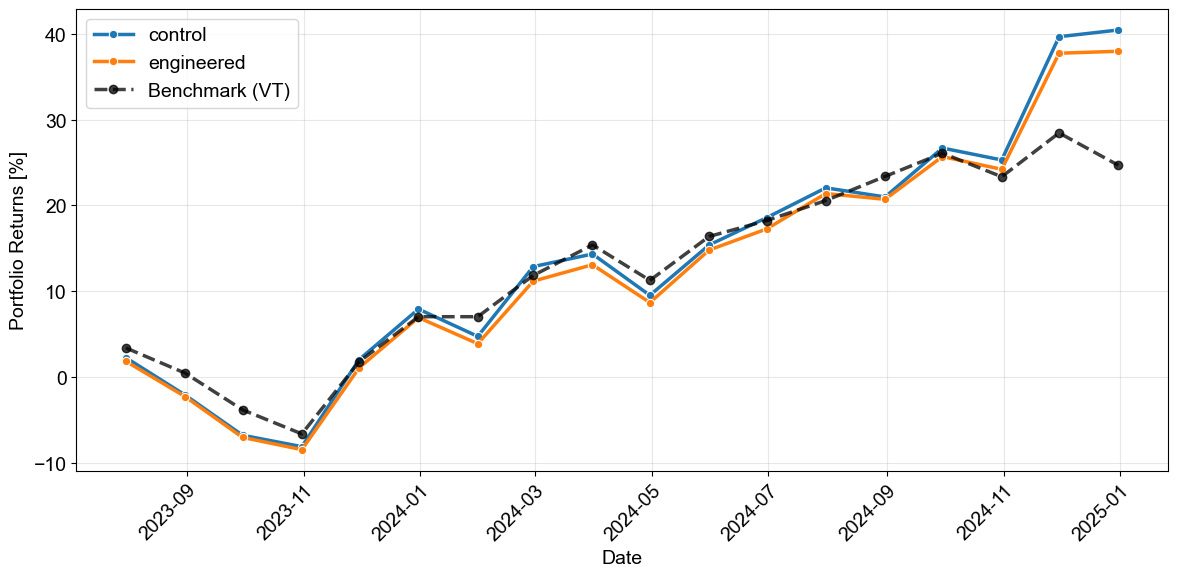

In [41]:
plot_timeline(
    portfolios_timeseries, 
    benchmark_timeseries, 
    'portfolio_cumulative_return', 
    'Portfolio Returns [%]', 
    ['cond', 'date'], 
    'performance_returns')

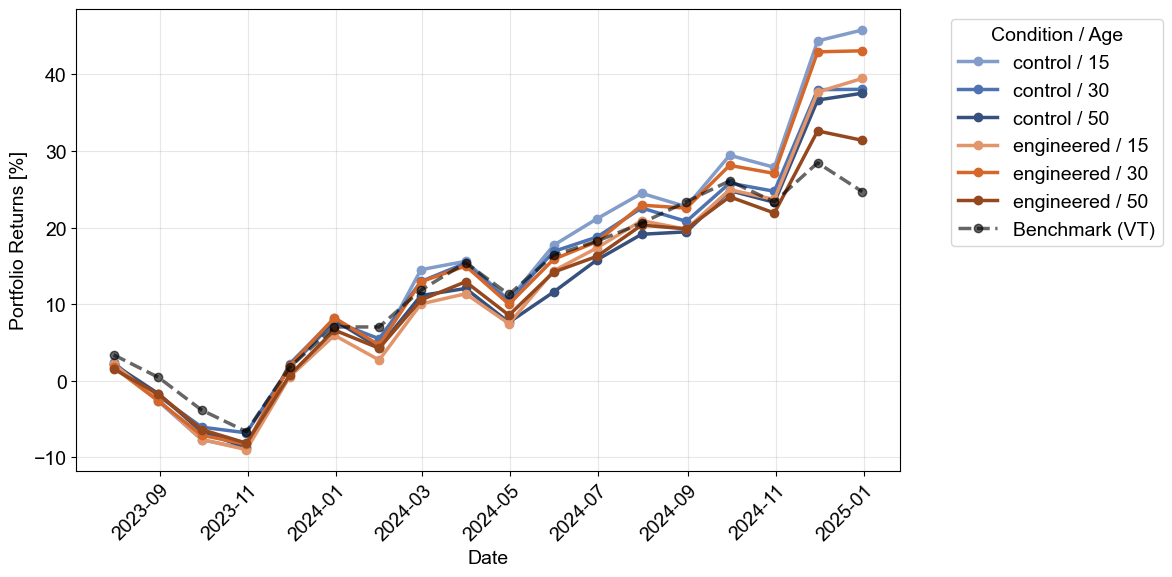

In [42]:
plot_timeline_detailed(
    portfolios_timeseries, 
    benchmark_timeseries, 
    'portfolio_cumulative_return',
    'Portfolio Returns [%]',
    'age',
    'Age',
    'performance_return_age'
)

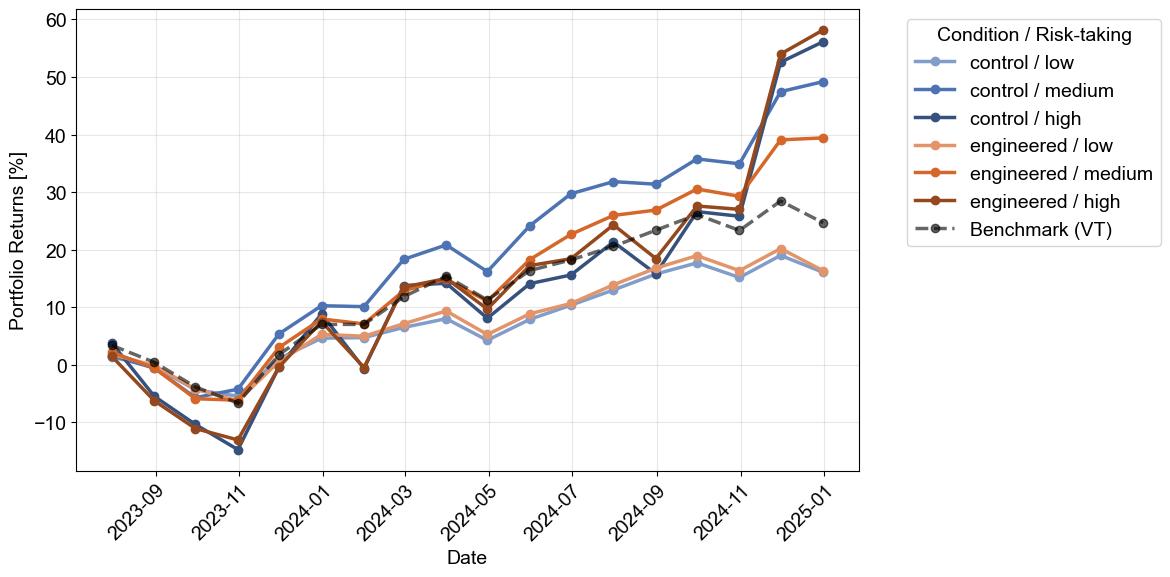

In [43]:
plot_timeline_detailed(
    portfolios_timeseries, 
    benchmark_timeseries, 
    'portfolio_cumulative_return',
    'Portfolio Returns [%]',
    'risk-taking',
    'Risk-taking',
    'performance_return_risk'
)

### Sharpe Ratio

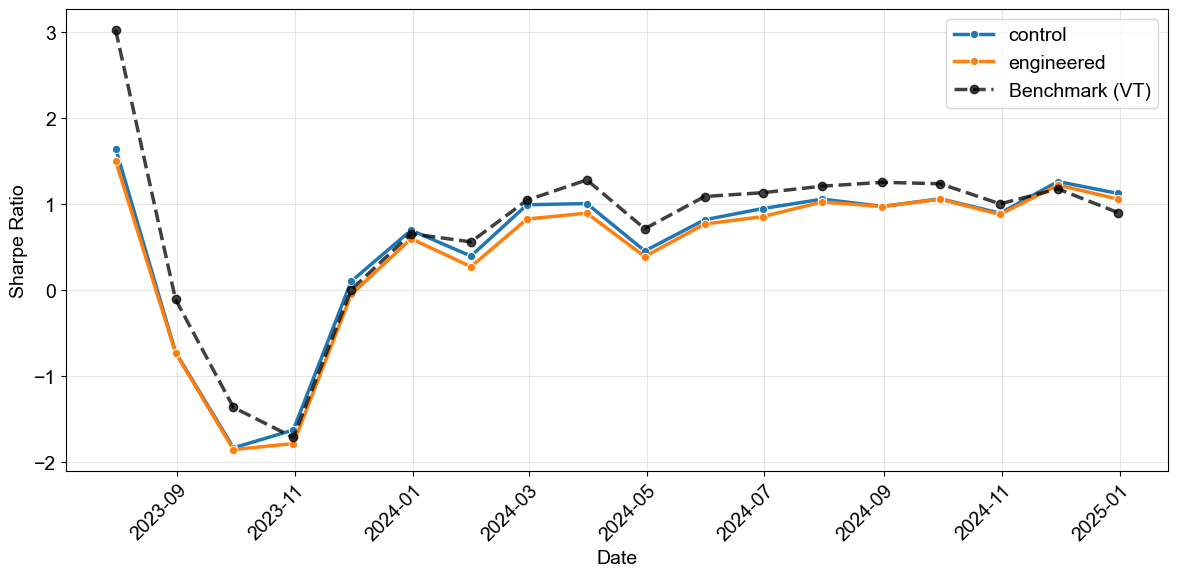

In [44]:
plot_timeline(
    portfolios_timeseries, 
    benchmark_timeseries, 
    'sharpe_ratio', 
    'Sharpe Ratio', 
    ['cond', 'date'], 
    'performance_sharpe')

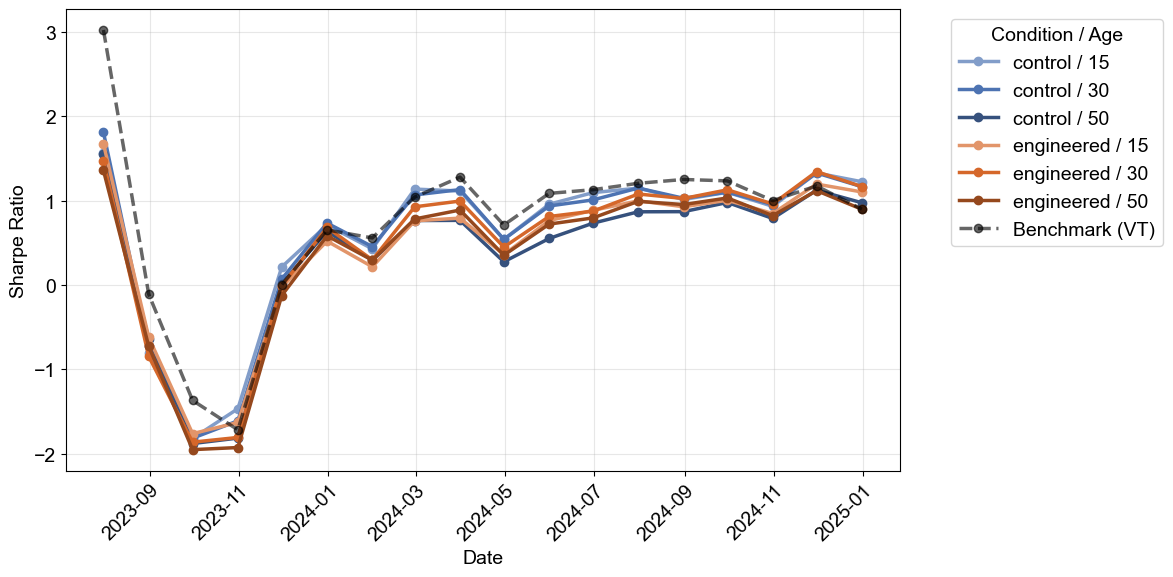

In [45]:
plot_timeline_detailed(
    portfolios_timeseries, 
    benchmark_timeseries, 
    'sharpe_ratio',
    'Sharpe Ratio',
    'age',
    'Age',
    'performance_sharpe_age'
)

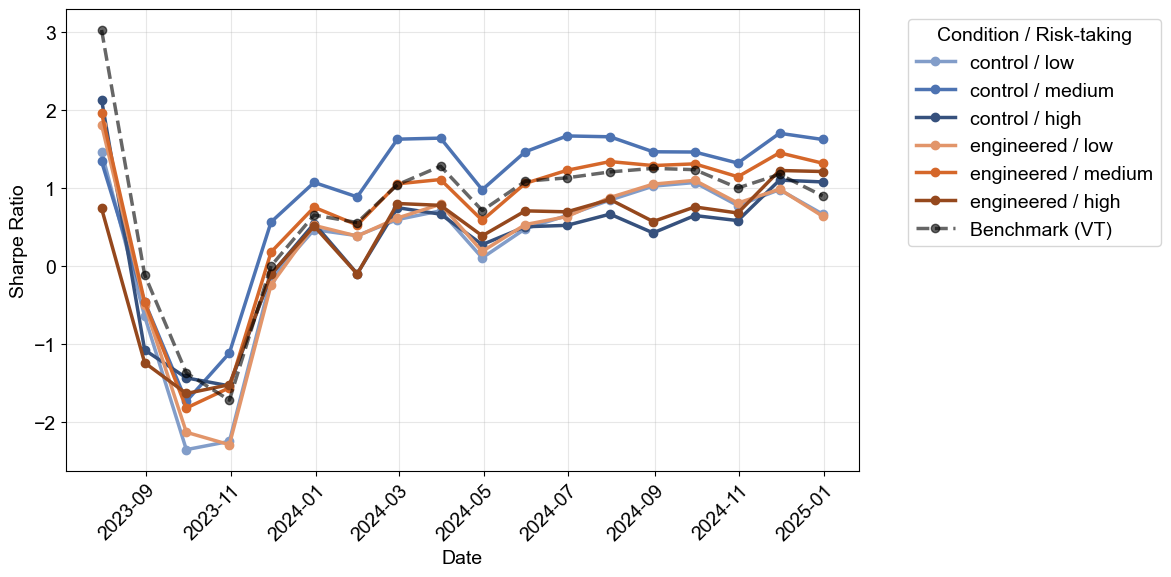

In [46]:
plot_timeline_detailed(
    portfolios_timeseries, 
    benchmark_timeseries, 
    'sharpe_ratio',
    'Sharpe Ratio',
    'risk-taking',
    'Risk-taking',
    'performance_sharpe_risk'
)

## Linear Mixed Model

In [47]:
benchmark_rows = benchmark_timeseries.copy()
benchmark_rows['cond'] = 'Benchmark'
benchmark_rows['risk-taking'] = 'Benchmark'  
benchmark_rows['age'] = 'Benchmark'
benchmark_rows['iteration'] = 'Benchmark'

print(portfolios_timeseries.shape)
print(benchmark_rows.shape)
df_comb = pd.concat([portfolios_timeseries, benchmark_rows], ignore_index=True).dropna()
df_comb.rename(columns={'risk-taking': 'risk_taking'}, inplace=True)
print(df_comb.shape)

(3240, 8)
(18, 8)
(3258, 8)


In [48]:
def calculate_mixed_model(df, column, group1, group2=None):
    if group2:
        df['label'] = df.apply(lambda row: f'({row[group1]}, {row[group2]})', axis=1)
    else:
        df['label'] = df[group1]

    lmm = smf.mixedlm(f'{column} ~ label + date', data=df, groups=df['date']).fit()
    print(lmm.summary())

### Returns

In [49]:
calculate_mixed_model(df_comb, 'portfolio_cumulative_return', 'cond')

                          Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      portfolio_cumulative_return
No. Observations:       3258         Method:                  REML                       
No. Groups:             18           Scale:                   134.3278                   
Min. group size:        181          Log-Likelihood:          -12579.6587                
Max. group size:        181          Converged:               Yes                        
Mean group size:        181.0                                                            
-----------------------------------------------------------------------------------------
                                          Coef.    Std.Err.     z    P>|z|  [0.025 0.975]
-----------------------------------------------------------------------------------------
Intercept                                  1.591       11.937  0.133 0.894 -21.805 24.987
label[T.control]                    

In [50]:
calculate_mixed_model(df_comb, 'portfolio_cumulative_return', 'cond', 'risk_taking')

                          Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      portfolio_cumulative_return
No. Observations:       3258         Method:                  REML                       
No. Groups:             18           Scale:                   116.5467                   
Min. group size:        181          Log-Likelihood:          -12346.0680                
Max. group size:        181          Converged:               Yes                        
Mean group size:        181.0                                                            
-----------------------------------------------------------------------------------------
                                          Coef.    Std.Err.     z    P>|z|  [0.025 0.975]
-----------------------------------------------------------------------------------------
Intercept                                  1.591       11.119  0.143 0.886 -20.202 23.384
label[T.(control, high)]            

In [51]:
calculate_mixed_model(df_comb, 'portfolio_cumulative_return', 'cond', 'age')

                          Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      portfolio_cumulative_return
No. Observations:       3258         Method:                  REML                       
No. Groups:             18           Scale:                   133.1000                   
Min. group size:        181          Log-Likelihood:          -12560.8185                
Max. group size:        181          Converged:               Yes                        
Mean group size:        181.0                                                            
-----------------------------------------------------------------------------------------
                                          Coef.    Std.Err.     z    P>|z|  [0.025 0.975]
-----------------------------------------------------------------------------------------
Intercept                                  1.591       11.882  0.134 0.893 -21.698 24.880
label[T.(control, 15)]              

### Sharpe Ratio

In [53]:
calculate_mixed_model(df_comb, 'sharpe_ratio', 'cond')

                        Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          sharpe_ratio
No. Observations:           3258             Method:                      REML        
No. Groups:                 18               Scale:                       0.4840      
Min. group size:            181              Log-Likelihood:              -3471.3683  
Max. group size:            181              Converged:                   Yes         
Mean group size:            181.0                                                     
--------------------------------------------------------------------------------------
                                         Coef.    Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------
Intercept                                 1.830       0.717  2.554 0.011  0.426  3.235
label[T.control]                         -0.214       0.165 -1.298 0

In [54]:
calculate_mixed_model(df_comb, 'sharpe_ratio', 'cond', 'risk_taking')

                        Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          sharpe_ratio
No. Observations:           3258             Method:                      REML        
No. Groups:                 18               Scale:                       0.4192      
Min. group size:            181              Log-Likelihood:              -3246.2636  
Max. group size:            181              Converged:                   Yes         
Mean group size:            181.0                                                     
--------------------------------------------------------------------------------------
                                         Coef.    Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------
Intercept                                 1.830       0.667  2.744 0.006  0.523  3.137
label[T.(control, high)]                 -0.412       0.155 -2.654 0

In [55]:
calculate_mixed_model(df_comb, 'sharpe_ratio', 'cond', 'age')

                        Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          sharpe_ratio
No. Observations:           3258             Method:                      REML        
No. Groups:                 18               Scale:                       0.4795      
Min. group size:            181              Log-Likelihood:              -3463.3961  
Max. group size:            181              Converged:                   Yes         
Mean group size:            181.0                                                     
--------------------------------------------------------------------------------------
                                         Coef.    Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------
Intercept                                 1.830       0.713  2.566 0.010  0.432  3.228
label[T.(control, 15)]                   -0.146       0.166 -0.883 0

## ANOVAs & t-tests (single date)

### Return

In [56]:
min_date = df_comb['date'].min()
max_date = df_comb['date'].max()
df_time = portfolios_timeseries[(portfolios_timeseries['date'] == min_date) | (portfolios_timeseries['date'] == max_date)]
benchmark_last = benchmark_timeseries[benchmark_timeseries['date'] == max_date].iloc[0]

In [57]:
def show_ttest(raw, column, groups, benchmark):
    for (llm, timepoint), group_data in raw.groupby(groups):
        benchmark_val = benchmark[benchmark['date'] == timepoint].iloc[0][column]
        group_values = group_data[column]
        t_statistic, p_value = stats.ttest_1samp(group_values, benchmark_val)
        d = group_values.mean() - benchmark_val
        print(f'group: ({llm}, {timepoint}) got t: {round(t_statistic,2)} p_value: {round(p_value,4)} dfs: {len(group_values)-1} benchmark: {round(benchmark_val, 2)} d: {round(d, 2)}')

def show_anova(df, column, group1, group2=None, onlyGroup=False):
    if group1 and group2:
        df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)
    else:
        df = df.copy()
        df.loc[:, 'label'] = df.loc[:, group1]
    
    model = ols(f'{column} ~ label', data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)
    tukey_results = pairwise_tukeyhsd(endog=df[column], groups=df['label'], alpha=0.05)
    print(tukey_results)

def calc_stats(raw, column, benchmark, group1, group2=None):
    show_anova(raw, column, group1, group2)
    groups = [group1, group2] if group2 != None else [group1]
    show_ttest(raw, column, groups, benchmark)
    
    grouped = raw.groupby(groups)[column]
    means = []
    std_devs = []
    sample_sizes = []
    if len(groups) > 1:
        means = grouped.mean().unstack()
        std_devs = grouped.std().unstack()
        sample_sizes = grouped.count().unstack()
    else:
        means = grouped.mean()
        std_devs = grouped.std()
        sample_sizes = grouped.count()
    standard_errors = std_devs / np.sqrt(sample_sizes)
    return means, std_devs, sample_sizes, standard_errors

def print_stats(raw, column, benchmark, group1, group2=None):
    means, std_devs, sample_sizes, standard_errors = calc_stats(raw, column, benchmark, group1, group2)
    
    print(f'means:\n{round(means, 2)}')
    print(f'stds:\n{round(std_devs,2)}')
    print(sample_sizes)

In [58]:
print_stats(df_time, 'portfolio_cumulative_return', benchmark_timeseries, 'cond', 'date')

/var/folders/w_/z6q2ww5x2p160wjkqhjn_9vr0000gn/T/ipykernel_14559/2996237200.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = df.apply(lambda row: f"({row[group1]}, {row[group2]})", axis=1)


                 sum_sq     df           F        PR(>F)
label     124660.053571    3.0  138.110716  2.367903e-59
Residual  107109.668716  356.0         NaN           NaN
                            Multiple Comparison of Means - Tukey HSD, FWER=0.05                             
              group1                            group2              meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------------------------------------
   (control, 2023-07-31 00:00:00)    (control, 2024-12-31 00:00:00)  38.2078    0.0  31.5335  44.8821   True
   (control, 2023-07-31 00:00:00) (engineered, 2023-07-31 00:00:00)  -0.4153 0.9985  -7.0896    6.259  False
   (control, 2023-07-31 00:00:00) (engineered, 2024-12-31 00:00:00)   35.726    0.0  29.0517  42.4003   True
   (control, 2024-12-31 00:00:00) (engineered, 2023-07-31 00:00:00)  -38.623    0.0 -45.2973 -31.9487   True
   (control, 2024-12-31 00:00:00) (engineered, 2024-12-31 00:00:00

### Sharpe Ratio

In [60]:
print_stats(df_time.dropna(), 'sharpe_ratio', benchmark_timeseries, 'cond', 'date')

              sum_sq     df         F    PR(>F)
label      22.211095    3.0  5.118026  0.001772
Residual  514.986942  356.0       NaN       NaN
                           Multiple Comparison of Means - Tukey HSD, FWER=0.05                            
              group1                            group2              meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------------------------
   (control, 2023-07-31 00:00:00)    (control, 2024-12-31 00:00:00)  -0.5226 0.0197 -0.9854 -0.0598   True
   (control, 2023-07-31 00:00:00) (engineered, 2023-07-31 00:00:00)  -0.1422 0.8576  -0.605  0.3206  False
   (control, 2023-07-31 00:00:00) (engineered, 2024-12-31 00:00:00)  -0.5882 0.0062  -1.051 -0.1254   True
   (control, 2024-12-31 00:00:00) (engineered, 2023-07-31 00:00:00)   0.3804 0.1482 -0.0824  0.8432  False
   (control, 2024-12-31 00:00:00) (engineered, 2024-12-31 00:00:00)  -0.0656 0.9832 -0.5284  0.3972  False
